# 🔋 Electric Vehicle Sales in India - Exploratory Data Analysis

## 📌 Objective:
To analyze the growth and distribution of Electric Vehicle (EV) sales across different Indian states by vehicle types, categories, and time. The goal is to identify trends and derive actionable insights that can support infrastructure, investment, and policy decisions.

**Tools Used:** Python, Pandas, Seaborn, Matplotlib  
**Dataset Source:** Clean Mobility Shift (scraped + preprocessed)

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [3]:
df = pd.read_csv(r'C:\Python Project\Electric Vehicles Sales\Electric Vehicle Sales by State in India.csv')
df.head(10)

,Year,Month_Name,Date,State,Vehicle_Class,Vehicle_Category,Vehicle_Type,EV_Sales_Quantity
0,2014.0,jan,1/1/2014,Andhra Pradesh,ADAPTED VEHICLE,Others,Others,0.0
1,2014.0,jan,1/1/2014,Andhra Pradesh,AGRICULTURAL TRACTOR,Others,Others,0.0
2,2014.0,jan,1/1/2014,Andhra Pradesh,AMBULANCE,Others,Others,0.0
3,2014.0,jan,1/1/2014,Andhra Pradesh,ARTICULATED VEHICLE,Others,Others,0.0
4,2014.0,jan,1/1/2014,Andhra Pradesh,BUS,Bus,Bus,0.0
5,2014.0,jan,1/1/2014,Andhra Pradesh,CASH VAN,Others,Others,0.0
6,2014.0,jan,1/1/2014,Andhra Pradesh,CRANE MOUNTED VEHICLE,Others,Others,0.0
7,2014.0,jan,1/1/2014,Andhra Pradesh,EDUCATIONAL INSTITUTION BUS,Bus,Institution Bus,0.0
8,2014.0,jan,1/1/2014,Andhra Pradesh,EXCAVATOR (COMMERCIAL),Others,Others,0.0
9,2014.0,jan,1/1/2014,Andhra Pradesh,FORK LIFT,Others,Others,0.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96845 entries, 0 to 96844
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Year               96845 non-null  float64
 1   Month_Name         96845 non-null  object 
 2   Date               96845 non-null  object 
 3   State              96845 non-null  object 
 4   Vehicle_Class      96845 non-null  object 
 5   Vehicle_Category   96845 non-null  object 
 6   Vehicle_Type       96845 non-null  object 
 7   EV_Sales_Quantity  96845 non-null  float64
dtypes: float64(2), object(6)
memory usage: 5.9+ MB


In [4]:
# Year type
df['Year'] = df['Year'].astype(int)

# Date to datetime
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# categories
cat_cols = ['Month_Name', 'State', 'Vehicle_Class', 'Vehicle_Category', 'Vehicle_Type']
df[cat_cols] = df[cat_cols].astype('category')

# shape
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
df.info()

Rows: 96845, Columns: 8
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96845 entries, 0 to 96844
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Year               96845 non-null  int64         
 1   Month_Name         96845 non-null  category      
 2   Date               96845 non-null  datetime64[ns]
 3   State              96845 non-null  category      
 4   Vehicle_Class      96845 non-null  category      
 5   Vehicle_Category   96845 non-null  category      
 6   Vehicle_Type       96845 non-null  category      
 7   EV_Sales_Quantity  96845 non-null  float64       
dtypes: category(5), datetime64[ns](1), float64(1), int64(1)
memory usage: 2.7 MB


In [5]:
# missing values
print("Missing values:\n", df.isnull().sum())

# duplicates
print("\nDuplicate rows:", df.duplicated().sum())

Missing values:
 Year                 0
Month_Name           0
Date                 0
State                0
Vehicle_Class        0
Vehicle_Category     0
Vehicle_Type         0
EV_Sales_Quantity    0
dtype: int64

Duplicate rows: 0


In [11]:
state_year = df.groupby(['State', 'Year'])['EV_Sales_Quantity'].sum().unstack().fillna(0)
growth = state_year.pct_change(axis=1) * 100

print(state_year)

Year                      2014.0  2015.0   2016.0   2017.0   2018.0   2019.0  \
State                                                                          
Andaman & Nicobar Island     0.0     0.0      0.0      0.0     20.0      2.0   
Andhra Pradesh              12.0     8.0     20.0      0.0   1165.0   2123.0   
Arunachal Pradesh            0.0     0.0      1.0      0.0      1.0      1.0   
Assam                        2.0    23.0     19.0   3833.0   7403.0  10867.0   
Bihar                       12.0    69.0   1100.0   3593.0   8469.0  12380.0   
Chandigarh                   0.0     2.0      1.0     23.0    213.0    506.0   
Chhattisgarh               123.0    86.0    192.0    945.0   1902.0   2744.0   
DNH and DD                   0.0     2.0      2.0      1.0     19.0     19.0   
Delhi                       48.0  3565.0  21688.0  18042.0  20961.0  23222.0   
Goa                          9.0     4.0     34.0     39.0     26.0     41.0   
Gujarat                     76.0    81.0

In [12]:
df['Cumulative_Sales'] = df.sort_values('Date').groupby('State')['EV_Sales_Quantity'].cumsum()

In [14]:
df[df['State'] == 'Maharashtra'][['Date', 'EV_Sales_Quantity', 'Cumulative_Sales']].sort_values('Date').head(15)

,Date,EV_Sales_Quantity,Cumulative_Sales
348,1/1/2014,0.0,85.0
371,1/1/2014,0.0,82.0
372,1/1/2014,3.0,85.0
373,1/1/2014,0.0,85.0
374,1/1/2014,0.0,85.0
375,1/1/2014,0.0,85.0
376,1/1/2014,0.0,85.0
377,1/1/2014,0.0,85.0
379,1/1/2014,0.0,0.0
380,1/1/2014,0.0,0.0


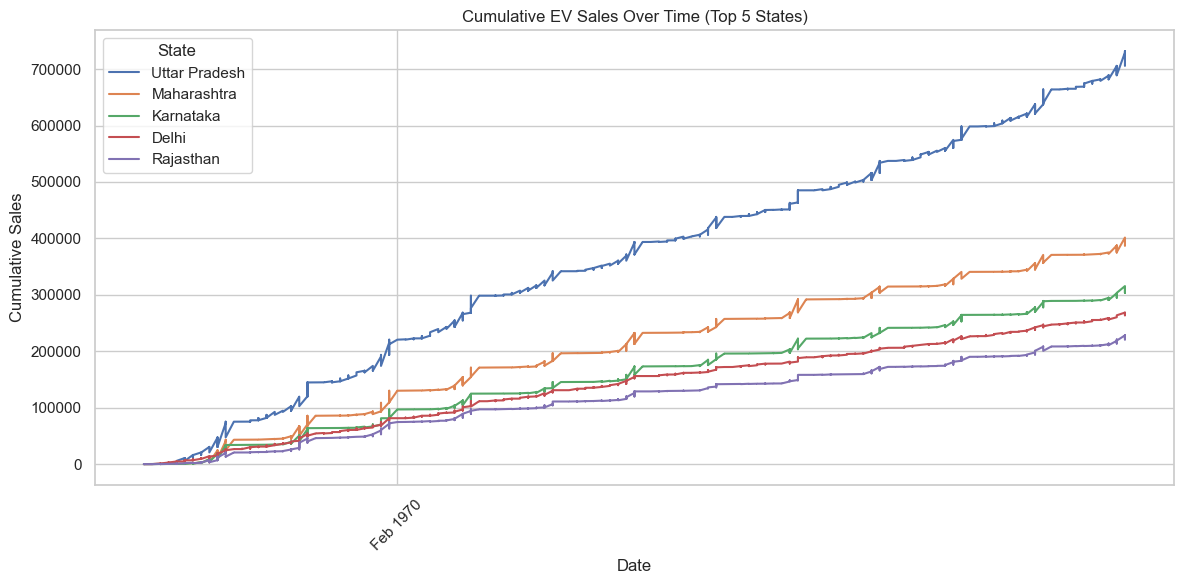

In [16]:
import matplotlib.dates as mdates

# Plot cumulative sales
plt.figure(figsize=(12, 6))

for state in top_states:
    state_data = df_top[df_top['State'] == state].sort_values('Date')
    plt.plot(state_data['Date'], state_data['Cumulative_Sales'], label=state)

# Format the x-axis dates
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))  # e.g., Jan 2021
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=6))  # every 6 months

plt.title('Cumulative EV Sales Over Time (Top 5 States)')
plt.xlabel('Date')
plt.ylabel('Cumulative Sales')
plt.legend(title='State')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

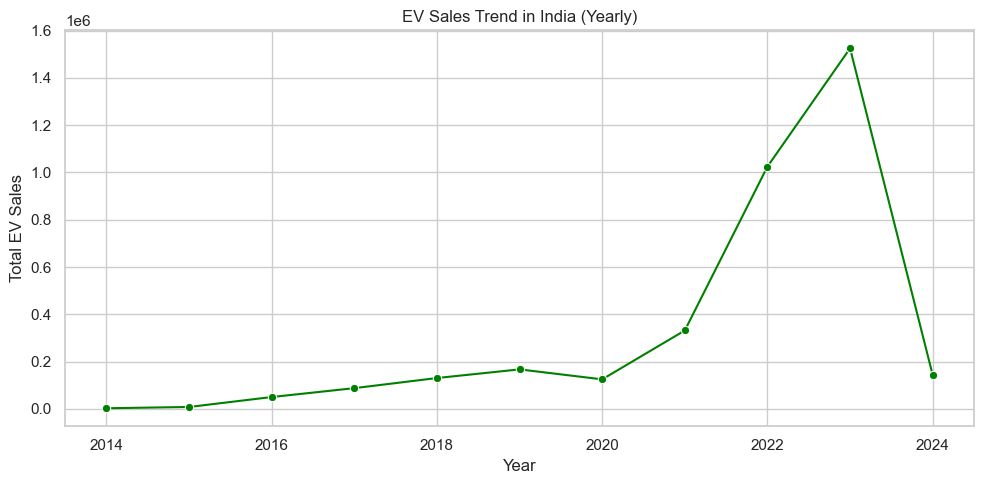

In [6]:
# yearly sum of EV sales
yearly_sales = df.groupby('Year')['EV_Sales_Quantity'].sum().reset_index()

plt.figure(figsize=(10, 5))
sns.lineplot(data=yearly_sales, x='Year', y='EV_Sales_Quantity', marker='o', color='green')
plt.title('EV Sales Trend in India (Yearly)')
plt.ylabel('Total EV Sales')
plt.xlabel('Year')
plt.grid(True)
plt.tight_layout()
plt.show()

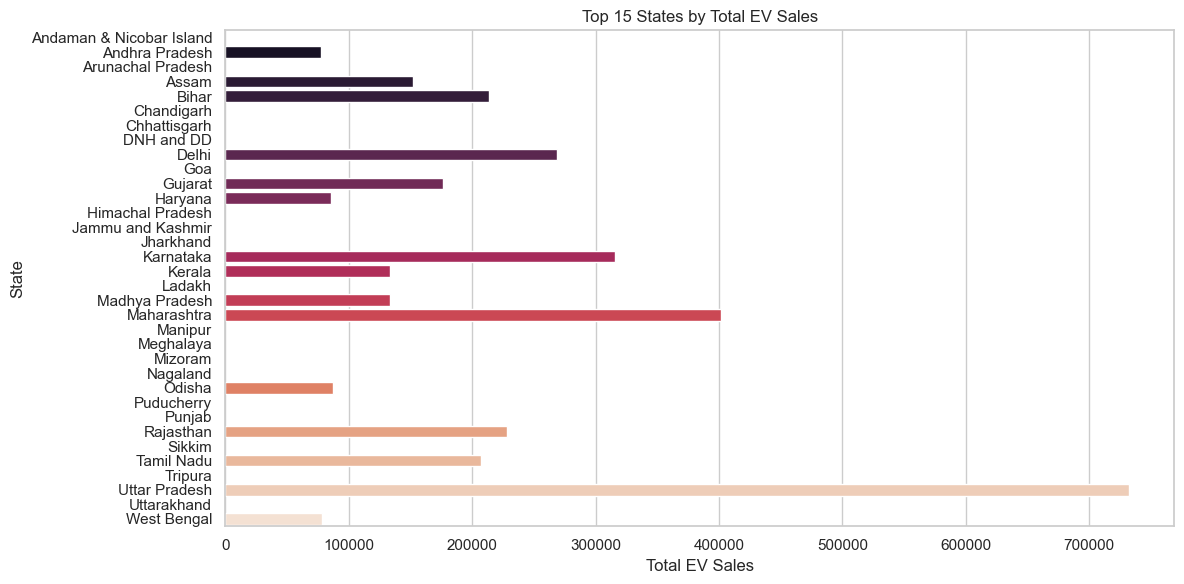

In [7]:
# state-wise total EV sales
top_states = df.groupby('State', observed=False)['EV_Sales_Quantity'].sum().sort_values(ascending=False).head(15)

top_states_df = top_states.reset_index()
plt.figure(figsize=(12, 6))
sns.barplot(data=top_states_df, x='EV_Sales_Quantity', y='State', hue='State', dodge=False, palette='rocket', legend=False)
plt.title('Top 15 States by Total EV Sales')
plt.xlabel('Total EV Sales')
plt.ylabel('State')
plt.tight_layout()
plt.show()

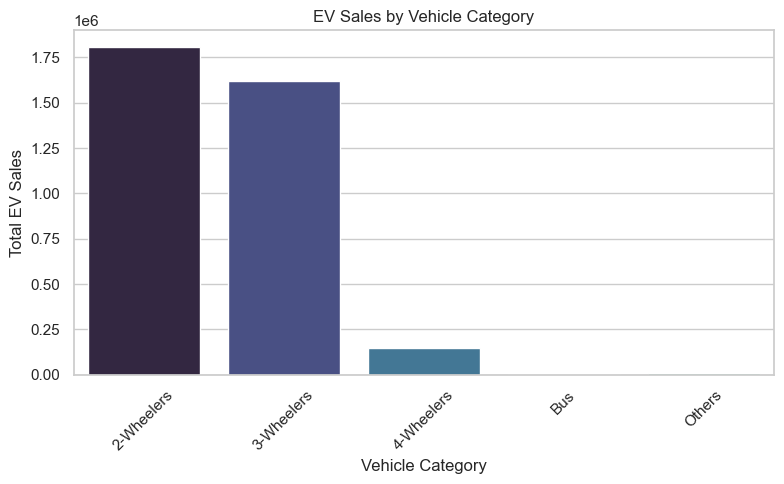

In [15]:
# total sales
category_sales = df.groupby('Vehicle_Category', observed=True)['EV_Sales_Quantity'].sum().sort_values(ascending=False)

category_sales_df = category_sales.reset_index()
category_sales_df.columns = ['Vehicle_Category', 'EV_Sales_Quantity']

plt.figure(figsize=(8, 5))
sns.barplot(
    data=category_sales_df,
    x='Vehicle_Category',
    y='EV_Sales_Quantity',
    hue='Vehicle_Category',
    dodge=False,
    palette='mako',
    legend=False
)
plt.title('EV Sales by Vehicle Category')
plt.ylabel('Total EV Sales')
plt.xlabel('Vehicle Category')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

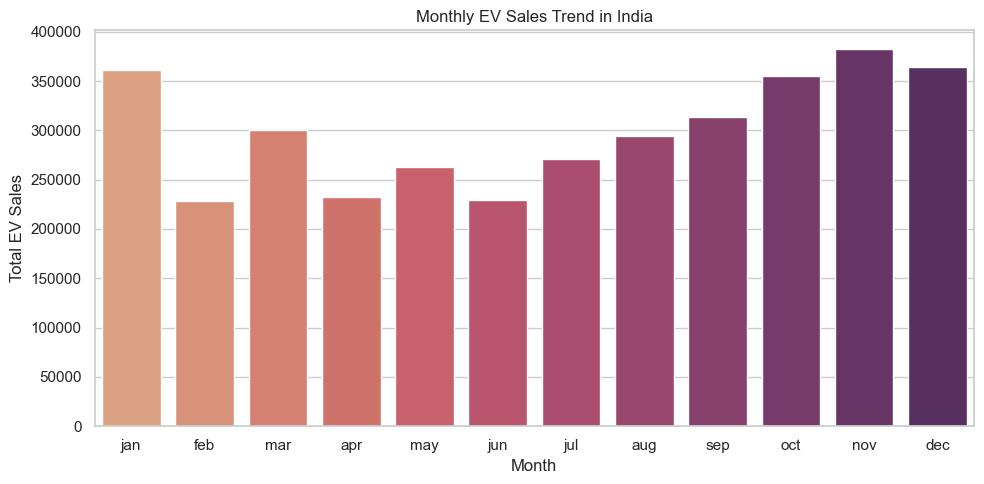

In [16]:
# Order of months
month_order = ['jan', 'feb', 'mar', 'apr', 'may', 'jun', 
               'jul', 'aug', 'sep', 'oct', 'nov', 'dec']

monthly_sales = df.groupby('Month_Name', observed=True)['EV_Sales_Quantity'].sum().reindex(month_order)

monthly_sales_df = monthly_sales.reset_index()
monthly_sales_df.columns = ['Month_Name', 'EV_Sales_Quantity']

plt.figure(figsize=(10, 5))
sns.barplot(
    data=monthly_sales_df,
    x='Month_Name',
    y='EV_Sales_Quantity',
    hue='Month_Name',
    palette='flare',
    dodge=False,
    legend=False
)
plt.title('Monthly EV Sales Trend in India')
plt.xlabel('Month')
plt.ylabel('Total EV Sales')
plt.tight_layout()
plt.show()

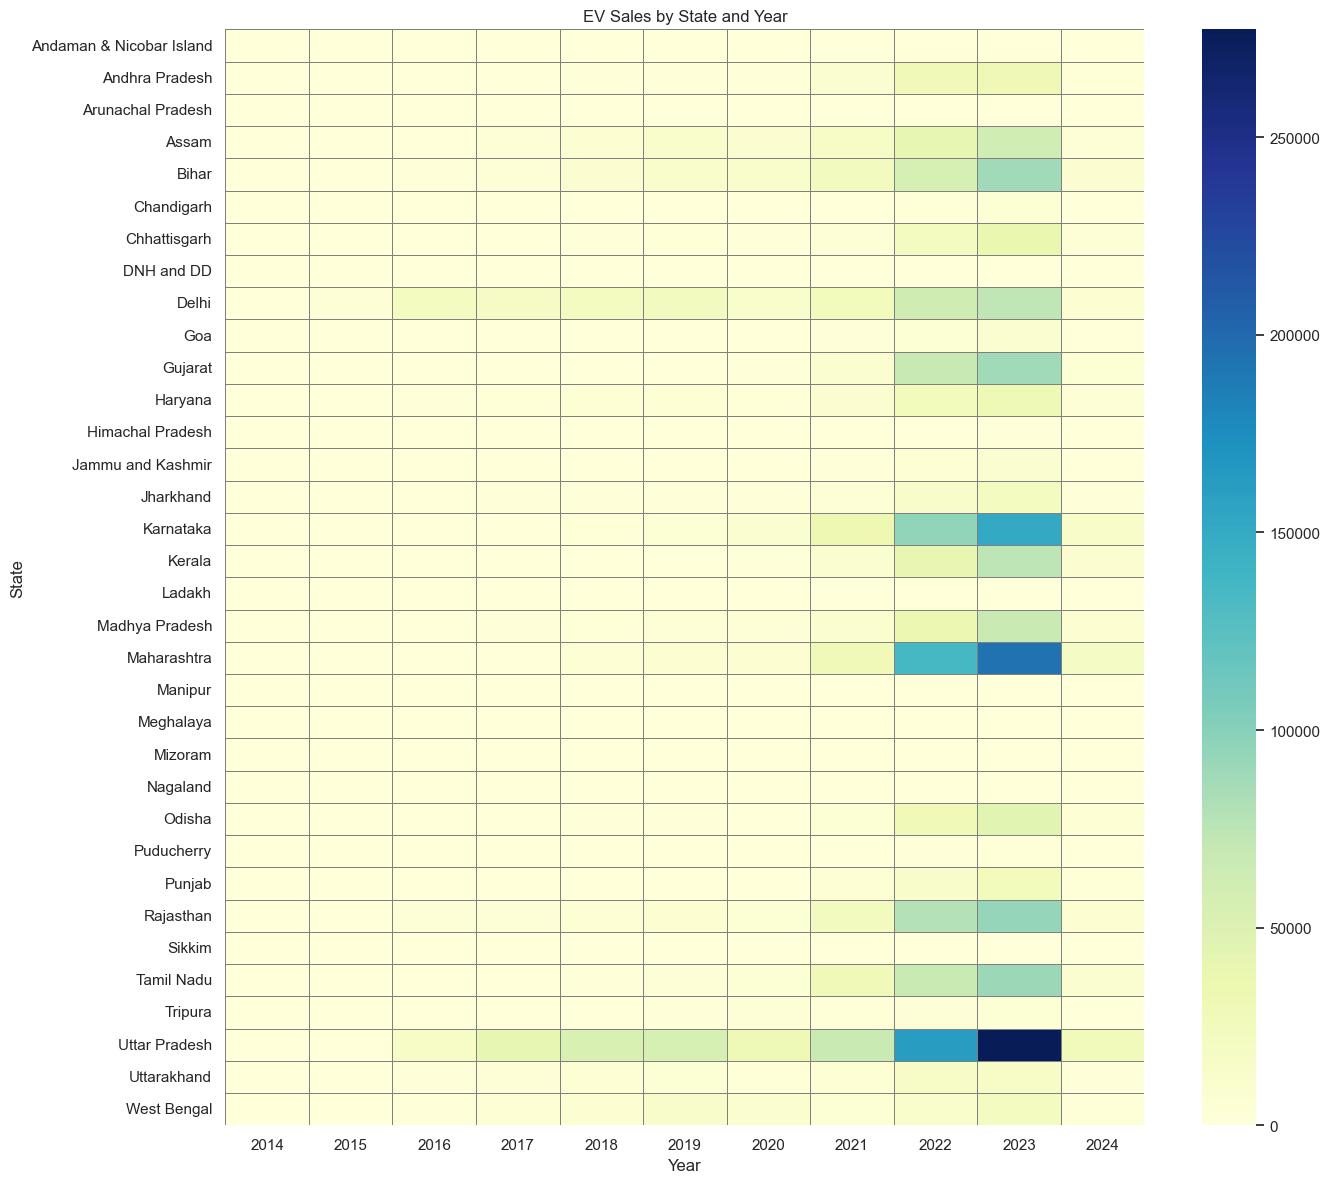

In [21]:
heatmap_data = df.pivot_table(
    values='EV_Sales_Quantity',
    index='State',
    columns='Year',
    aggfunc='sum',
    fill_value=0,
    observed=True
    )

plt.figure(figsize=(14, 12))
sns.heatmap(
    heatmap_data,
    cmap='YlGnBu',
    linewidths=0.5,
    linecolor='gray'
)
plt.title('EV Sales by State and Year')
plt.xlabel('Year')
plt.ylabel('State')
plt.tight_layout()
plt.show()

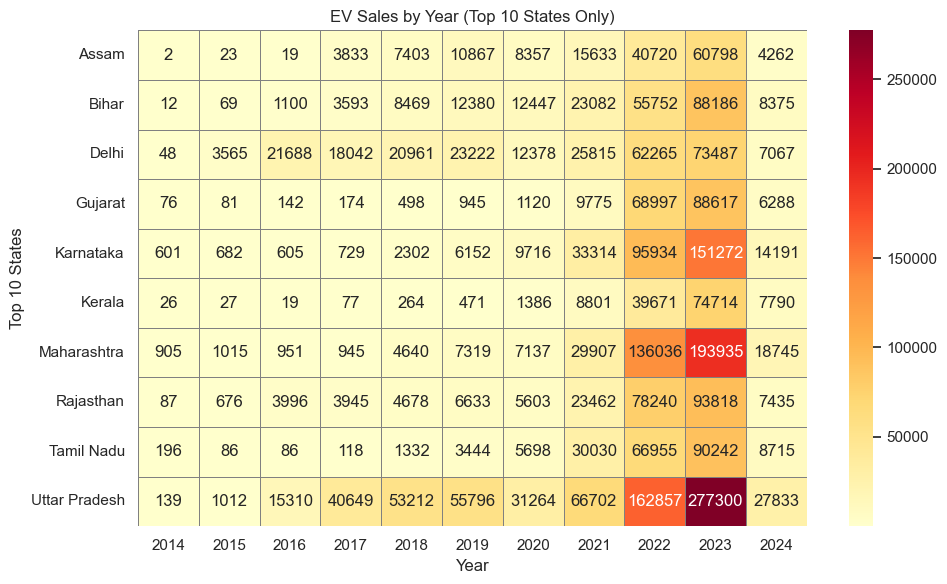

In [29]:
# top 10 states by total EV sales
top_10_states = df.groupby('State', observed=True)['EV_Sales_Quantity'].sum().sort_values(ascending=False).head(10).index

df_top_states = df[df['State'].isin(top_10_states)]

heatmap_data_top = df_top_states.pivot_table(
    values='EV_Sales_Quantity',
    index='State',
    columns='Year',
    aggfunc='sum',
    fill_value=0,
    observed=True
    )

plt.figure(figsize=(10, 6))
sns.heatmap(
    heatmap_data_top,
    cmap='YlOrRd',
    linewidths=0.5,
    linecolor='gray',
    annot=True,
    fmt='.0f'
)
plt.title('EV Sales by Year (Top 10 States Only)')
plt.xlabel('Year')
plt.ylabel('Top 10 States')
plt.tight_layout()
plt.show()

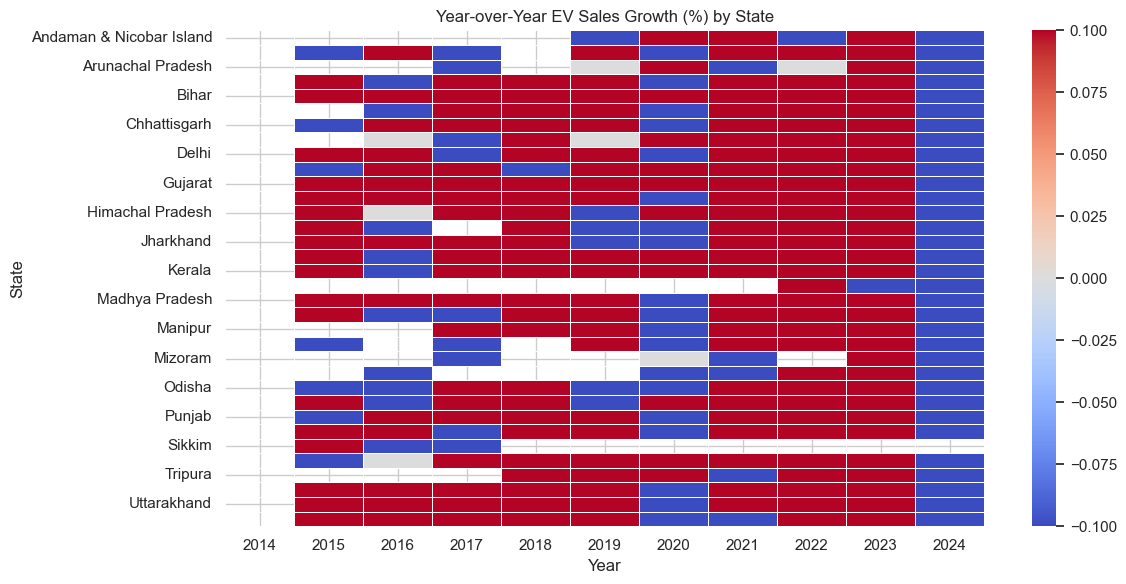

In [31]:
state_year = df.groupby(['State', 'Year'],observed=True)['EV_Sales_Quantity'].sum().unstack().fillna(0)
growth_rate = state_year.pct_change(axis=1) * 100  # YoY %

plt.figure(figsize=(12, 6))
sns.heatmap(growth_rate, cmap='coolwarm', annot=False, linewidths=0.5)
plt.title('Year-over-Year EV Sales Growth (%) by State')
plt.xlabel('Year')
plt.ylabel('State')
plt.tight_layout()
plt.show()

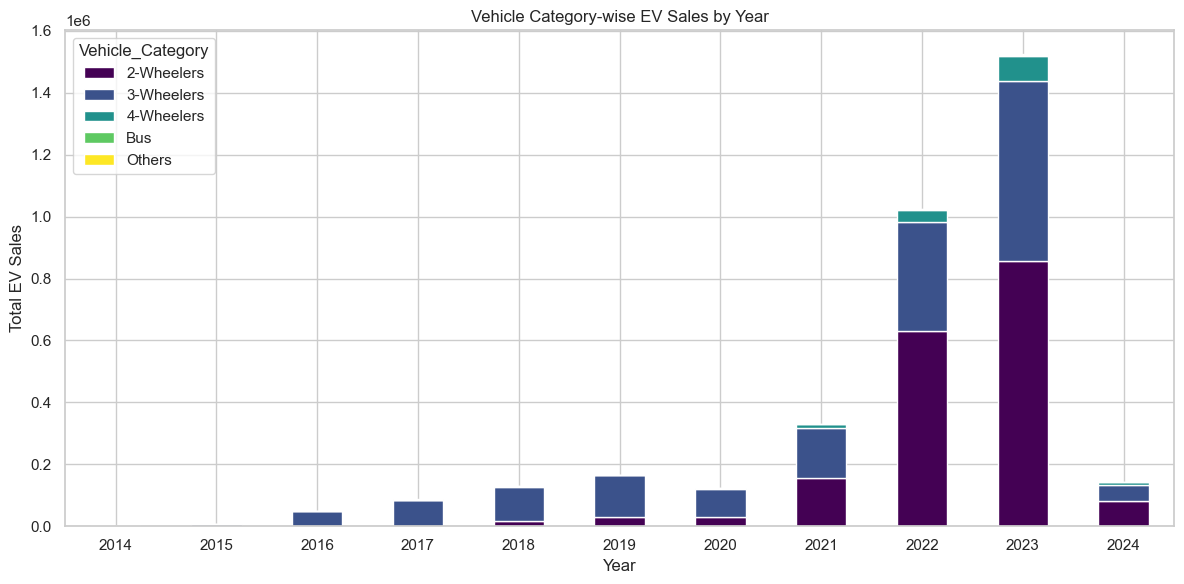

In [34]:
category_year = df.groupby(['Year', 'Vehicle_Category'],observed=True)['EV_Sales_Quantity'].sum().unstack().fillna(0)

category_year.plot(kind='bar', stacked=True, colormap='viridis', figsize=(12, 6))
plt.title('Vehicle Category-wise EV Sales by Year')
plt.ylabel('Total EV Sales')
plt.xlabel('Year')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

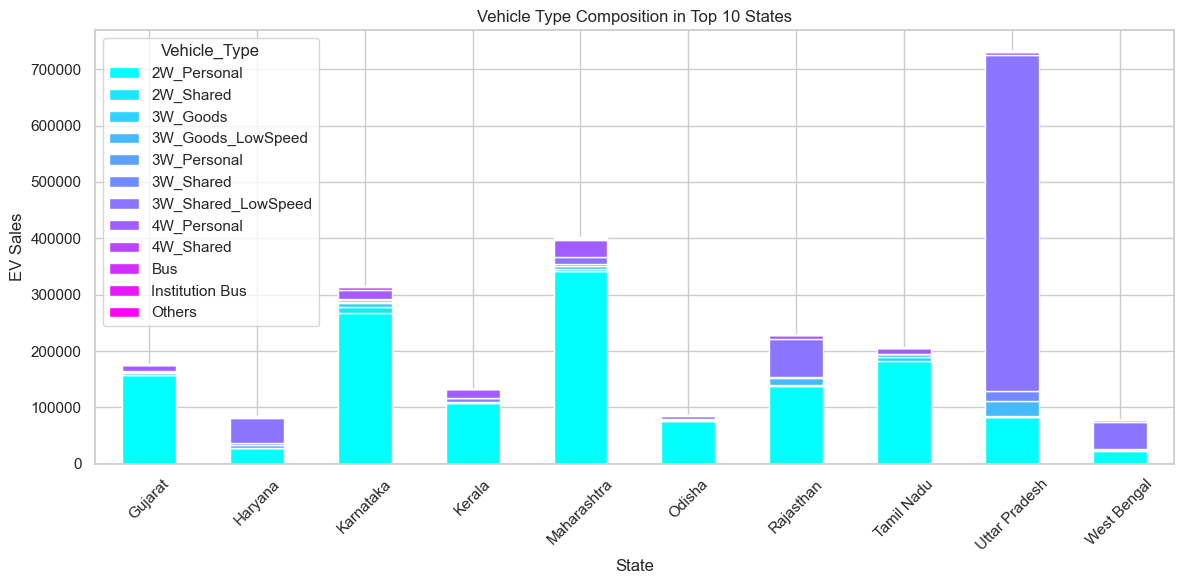

In [35]:
top_states = df['State'].value_counts().head(10).index
state_type = df[df['State'].isin(top_states)].groupby(['State', 'Vehicle_Type'],observed=True)['EV_Sales_Quantity'].sum().unstack().fillna(0)

state_type.plot(kind='bar', stacked=True, colormap='cool', figsize=(12, 6))
plt.title('Vehicle Type Composition in Top 10 States')
plt.ylabel('EV Sales')
plt.xlabel('State')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 📈 Visual Insights
- 🔝 Top states by EV sales volume
- 🛵 Vehicle category dominance (2W, 3W, 4W)
- 📅 Monthly/seasonal trends in EV adoption
- 🗺️ Heatmap of state-wise growth year over year
- 📊 Cumulative EV sales curves for top states
- 📈 YoY growth percentage heatmap

## 📌 Conclusion

- EV sales in India have grown consistently from 2014 to 2023, with massive spikes post-2020.
- Uttar Pradesh, Maharashtra, and Karnataka lead in total EV sales volume.
- Two-wheelers (2W) dominate the market, but three-wheelers (3W) show strong regional growth.
- Monthly trends show steady year-round sales, with mild surges around mid-year.
- Some states like Assam and Bihar have shown impressive YoY growth in recent years.
- The cumulative growth curve clearly shows a national shift toward clean mobility adoption.